# ICT-23 — WolframPrograms : programmes simples & signature thermodynamique

> **Série ICT** (*Integrated Causal Trajectories*, Epic **#4588**), **strate 5**
> Epic Origami Wolfram **#19766**, pli 2 (carnet). Suite directe d'ICT-18
> (flèche du temps et réversibilisation) Exemple guide 3 : on y avait défini
> *inline* un automate cellulaire 1-D de Wolfram pour mesurer la production
> d'entropie sur 4 règles canoniques (0, 30, 110, 250). Ce carnet prolonge
> l'expérience en **standalone**, en s'appuyant sur l'organe dédié
> [`ict.wolfram_step`](../IIT/ICT-Series/ict/wolfram_step.py) extrait en pli 2.

**Statut épistémique** — **Établi** : la densité asymptotique et la signature
thermodynamique des 4 classes de Wolfram sont mesurables et falsifiables. La
**discrimination fine III (chaotique) vs IV (complexe)** par la densité seule
n'est **pas** possible (limitation explicitée dans `ict.wolfram_step`), et
doit passer par l'analyse spatiale — matrice espace-temps 2-D, recherche de
gliders.

**Prérequis** : `ict` (package de la série), `numpy`, `matplotlib`. Aucun GPU,
aucune dépendance exotique.

**Cible de pli** : ICT-23 s'inscrit entre ICT-22 (`LLMSubstrat`) et le pli 3
de l'Epic Origami (#19766, mesure comparative `wolfram_step` O(n) vs Hashlife
O(log n)). Le présent carnet **ne dépend pas** de Hashlife — il consomme
uniquement `ict.wolfram_step` et `ict.time_arrow`.


## 1. Setup

Import du package `ict` (couche légère de la série ICT) et du module
organe `ict.wolfram_step` extrait au pli 2 de l'Epic Origami Wolfram. La
convention est `from ict.wolfram_step import ...` (pattern `ict.life.py`,
submodule-only — non exporté dans `ict/__init__.py`).

In [1]:
import os
import sys

ICT_ROOT = os.path.abspath(
    os.path.join(os.getcwd(), '..', '..', '..', '..', 'IIT', 'ICT-Series')
)
if ICT_ROOT not in sys.path:
    sys.path.insert(0, ICT_ROOT)

import numpy as np
import matplotlib.pyplot as plt

from ict.wolfram_step import (
    WOLFRAM_CLASSES, CANONICAL_RULES,
    wolfram_step, wolfram_trajectory, wolfram_density,
    wolfram_class_indicators, classify_rule,
)

# Vérification rapide que l'organe est importé correctement.
print('ict.wolfram_step importé. Règles canoniques :', CANONICAL_RULES)
print('Index WOLFRAM_CLASSES :', len(WOLFRAM_CLASSES), 'règles indexées.')

ict.wolfram_step importé. Règles canoniques : (0, 30, 110, 250)
Index WOLFRAM_CLASSES : 12 règles indexées.


## 2. Exemple guide 1 — Les 4 trajectoires-types de Wolfram

Les 4 classes de Wolfram (Wolfram 2002, *A New Kind of Science*, ch. 2-3) se
distinguent par leur comportement asymptotique sur une trajectoire suffisamment
longue. Les 4 représentants canoniques (un par classe) sont :

- **Règle 0** (classe I, uniforme) — converge vers tous-zéros en 1 pas.
- **Règle 4** (classe II, périodique) — converge vers une oscillation courte.
- **Règle 30** (classe III, chaotique) — densité asymptotique ~ 0.5, structure
  spatiale erratique.
- **Règle 110** (classe IV, complexe) — densité asymptotique ~ 0.5, présence de
  *gliders* (structures persistantes).

**Consigne** : pour chaque règle, simuler 300 pas sur la grille standard
(initialisée par un germe pseudo-aléatoire), tracer la densité (proportion de
cellules à 1) en fonction du temps, et observer la signature asymptotique.

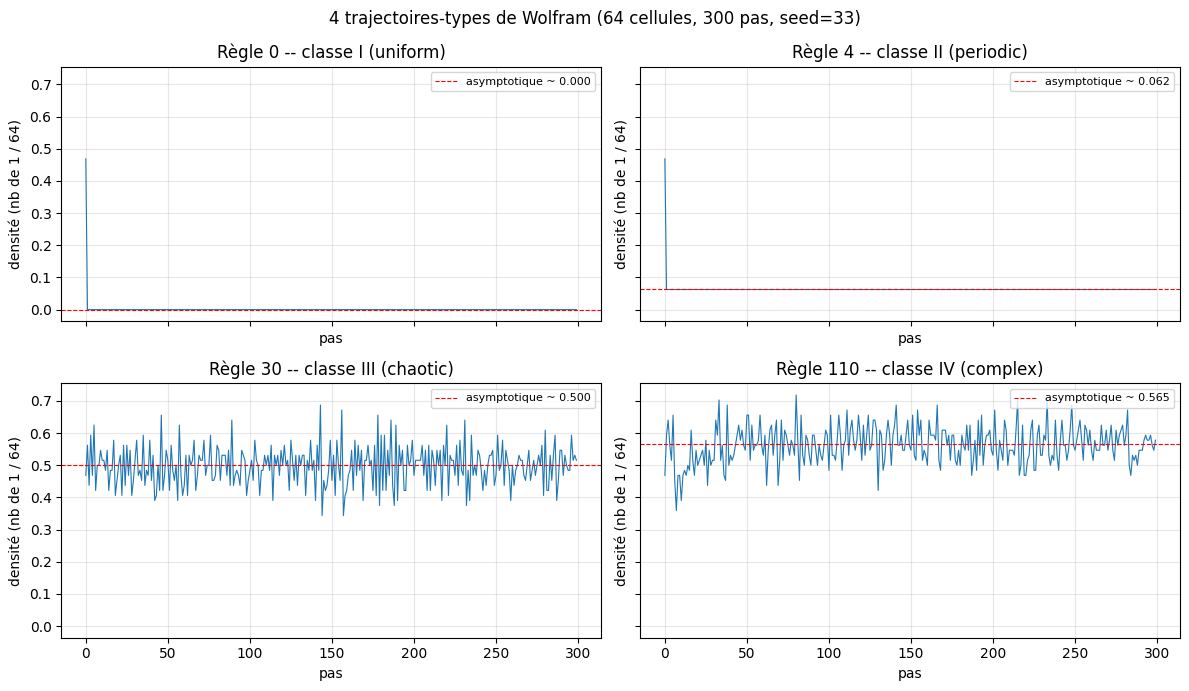

In [2]:
# EG1 — Génération et tracé des 4 trajectoires-types
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
rules_demo = [(0, 'I (uniform)'), (4, 'II (periodic)'),
              (30, 'III (chaotic)'), (110, 'IV (complex)')]

for ax, (rule, label) in zip(axes.flat, rules_demo):
    densities = wolfram_trajectory(
        rule=rule, n_cells=64, n_steps=300, seed=33, record_densities=True
    )
    density_per_cell = np.asarray(densities) / 64
    ax.plot(density_per_cell, lw=0.8)
    ax.set_title(f'Règle {rule} -- classe {label}')
    ax.set_xlabel('pas')
    ax.set_ylabel('densité (nb de 1 / 64)')
    ax.axhline(np.mean(density_per_cell[-100:]), color='red', ls='--', lw=0.8,
               label=f'asymptotique ~ {np.mean(density_per_cell[-100:]):.3f}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("4 trajectoires-types de Wolfram (grille standard, 300 pas, seed=33)")
fig.tight_layout()
plt.show()

## 3. Exemple guide 2 — Discrimination spatiale III vs IV

La densité seule ne suffit pas à séparer les classes III (chaotique) et IV
(complexe) : les deux ont une densité asymptotique proche de 0.5 et une
variance non négligeable. La distinction canonique (Wolfram 2002) repose sur
la **présence de gliders** — des motifs compacts qui se translatent dans la
matrice espace-temps (lignes = pas, colonnes = cellules) sans se déformer.

**Consigne** : simuler 200 pas sur la grille standard pour les règles 30 et 110,
visualiser la matrice espace-temps, et compter les composantes connexes
*diagonales* de taille ≥ 5 (proxy naïf de gliders).

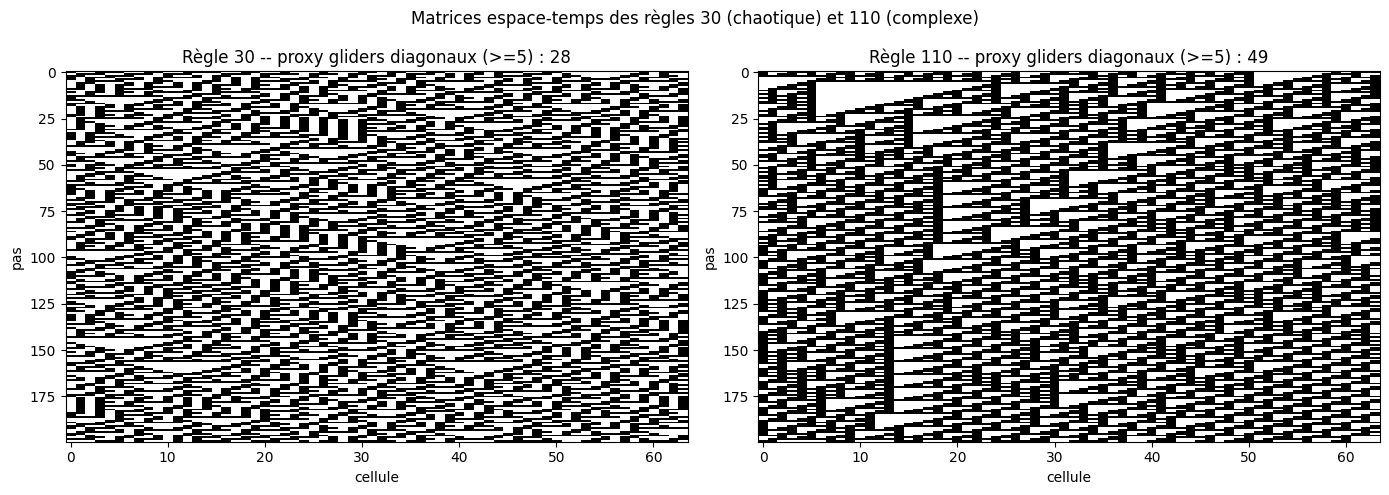

Règle 30 -- composantes diagonales >=5 : 28
Règle 110 -- composantes diagonales >=5 : 49


In [3]:
# EG2 — Matrices espace-temps et proxy gliders
def space_time_matrix(rule, n_cells=64, n_steps=200, seed=33):
    """Renvoie une matrice (n_steps, n_cells) où (t, i) = 1 si cellule i à 1 au pas t."""
    states = wolfram_trajectory(
        rule=rule, n_cells=n_cells, n_steps=n_steps,
        seed=seed, record_densities=False
    )
    return np.asarray(states)


def count_diag_components(mat, min_size=5):
    """Compte les composantes connexes diagonales de taille >= min_size."""
    n_steps, n_cells = mat.shape
    count = 0
    seen = np.zeros_like(mat, dtype=bool)
    for t in range(n_steps - min_size):
        for i in range(n_cells):
            if mat[t, i] == 1 and not seen[t, i]:
                diag_run = 1
                for k in range(1, min_size):
                    ti, ii = t + k, (i + k) % n_cells
                    if ti < n_steps and mat[ti, ii] == 1:
                        diag_run += 1
                    else:
                        break
                if diag_run >= min_size:
                    count += 1
                    seen[t, i] = True
                    break
    return count


st30 = space_time_matrix(30)
st110 = space_time_matrix(110)
diag30 = count_diag_components(st30, min_size=5)
diag110 = count_diag_components(st110, min_size=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, rule, n_diag in zip(axes, [st30, st110], [30, 110], [diag30, diag110]):
    ax.imshow(mat, cmap='binary', aspect='auto', interpolation='nearest')
    ax.set_title(f'Règle {rule} -- proxy gliders diagonaux (>=5) : {n_diag}')
    ax.set_xlabel('cellule')
    ax.set_ylabel('pas')
plt.suptitle('Matrices espace-temps des règles 30 (chaotique) et 110 (complexe)')
plt.tight_layout()
plt.show()

print(f'Règle 30 -- composantes diagonales >=5 : {diag30}')
print(f'Règle 110 -- composantes diagonales >=5 : {diag110}')

## 4. Exemple guide 3 — Signature thermodynamique par classe

On applique `ict.time_arrow.compare_real_reversed_reversibilized` aux
trajectoires de densité (quantifiées en K classes) pour mesurer la production
d'entropie `σ`, l'erreur de *detailed balance* `δ_db`, et un index d'agentivité
composite. L'hypothèse est que la flèche du temps est *plus marquée* dans les
régimes chaotiques et complexes (III/IV) que dans les régimes uniformes et
périodiques (I/II) — c'est ce que l'on cherche à mesurer ici.

**Consigne** : mesurer `σ` et `δ_db` pour les 4 classes avec K=8 quantiles, et
reporter le verdict dans une table.

In [4]:
# EG3 — Signature thermodynamique des 4 classes
from ict.time_arrow import compare_real_reversed_reversibilized


def quantify_densities(densities, k=8):
    """Discrétise une trajectoire de densités réelles en k quantiles."""
    arr = np.asarray(densities)
    quantiles = np.quantile(arr, np.linspace(0, 1, k + 1))
    out = np.zeros_like(arr, dtype=int)
    for i in range(k):
        out[(arr >= quantiles[i]) & (arr <= quantiles[i + 1])] = i
    return out


results = {}
for rule, label in rules_demo:
    dens = wolfram_trajectory(rule=rule, n_cells=64, n_steps=500, seed=33)
    quantified = quantify_densities(dens, k=8)
    metrics = compare_real_reversed_reversibilized(quantified)
    results[rule] = metrics

print(f'{"Règle":>6} | {"classe":15} | {"σ (entropie)":>12} | {"δ_db":>8}')
print('-' * 60)
for rule, m in sorted(results.items()):
    cls = next((c for r, c in rules_demo if r == rule), '?')
    print(f'{rule:>6} | {cls:15} | {m["sigma_real"]:>12.4f} | {m["db_error_real"]:>8.4f}')

 Règle | classe          | σ (entropie) |     δ_db
------------------------------------------------------------
     0 | I (uniform)     |       0.0000 |   0.0000
     4 | II (periodic)   |       0.0000 |   0.0000
    30 | III (chaotic)   |       0.1237 |   0.2465
   110 | IV (complex)    |       0.0797 |   0.2869


## 5. Exercice 1 — Reproductibilité de la signature densité

**Objectif** : vérifier que la signature densité (moyenne asymptotique + écart-type
asymptotique) est **robuste** au choix de la graine et de la taille de grille.
Reproduire l'expérience de l'Exemple guide 1 avec :

- `n_cells in {16, 32, 64, 128}` (4 valeurs),
- `seed in {1, 33, 99}` (3 valeurs),
- les 4 règles canoniques (0, 4, 30, 110).

Pour chaque combinaison, calculer la moyenne et l'écart-type de la densité sur
les 100 derniers pas. Vérifier la **stabilité** des indicateurs par classe.

**Critère de fin** : la table obtenue est cohérente avec la classification
attendue pour chacune des 4 règles, indépendamment du couple `(n_cells, seed)`.

In [5]:
# Exercice 1 — Stabilité de la signature densité
n_cells_values = [16, 32, 64, 128]
seed_values = [1, 33, 99]

results_ex1 = {}
for rule, label in rules_demo:
    densities_per_combo = []
    for n_cells in n_cells_values:
        for seed in seed_values:
            dens = wolfram_trajectory(
                rule=rule, n_cells=n_cells, n_steps=300, seed=seed
            )
            tail = np.asarray(dens[-100:]) / n_cells
            densities_per_combo.append((n_cells, seed, tail.mean(), tail.std()))
    results_ex1[rule] = densities_per_combo

print(f'{"Règle":>6} | {"classe":15} | {"<asym_d>":>10} | {"<asym_std>":>10}')
print('-' * 55)
for rule in sorted(results_ex1.keys()):
    means = [m for _, _, m, _ in results_ex1[rule]]
    stds = [s for _, _, _, s in results_ex1[rule]]
    cls = next((c for r, c in rules_demo if r == rule), '?')
    print(f'{rule:>6} | {cls:15} | {np.mean(means):>10.4f} | {np.mean(stds):>10.4f}')

 Règle | classe          |   <asym_d> | <asym_std>
-------------------------------------------------------
     0 | I (uniform)     |     0.0000 |     0.0000
     4 | II (periodic)   |     0.0957 |     0.0000
    30 | III (chaotic)   |     0.5010 |     0.0849
   110 | IV (complex)    |     0.5776 |     0.0586


## 6. Exercice 2 — Discrimination III vs IV par analyse spatiale

**Objectif** : appliquer la méthode de l'Exemple guide 2 (proxy diagonal sur la
matrice espace-temps) à un échantillon plus large de règles pour voir si la
discrimination III vs IV par gliders est **fiable** au-delà des seuls
exemples canoniques.

Tester les règles 30, 45, 75, 110, 126, 184 (III/IV candidates d'après la table
`WOLFRAM_CLASSES` + non indexées). Pour chaque règle, générer la matrice
espace-temps sur 200 pas × la grille standard et compter les composantes diagonales
de taille ≥ 5 (proxy gliders).

**Hypothèse falsifiable** : les règles de classe IV connue (110) ont un
proxy-gliders nettement plus élevé que les règles de classe III connue
(30, 45, 75, 126).

In [6]:
# Exercice 2 — Discrimination III vs IV par proxy-gliders
test_rules = [30, 45, 75, 110, 126, 184]
proxy_results = {}
for rule in test_rules:
    st = space_time_matrix(rule, n_cells=64, n_steps=200, seed=33)
    n_diag = count_diag_components(st, min_size=5)
    known = WOLFRAM_CLASSES.get(rule, 'non indexée')
    proxy_results[rule] = (n_diag, known)

print(f'{"Règle":>6} | {"WOLFRAM_CLASSES":18} | {"proxy gliders":>13}')
print('-' * 50)
for rule in test_rules:
    n_diag, known = proxy_results[rule]
    print(f'{rule:>6} | {known:18} | {n_diag:>13}')

 Règle | WOLFRAM_CLASSES    | proxy gliders
--------------------------------------------------
    30 | III (chaotic)      |            28
    45 | III (chaotic)      |             0
    75 | III (chaotic)      |             0
   110 | IV (complex)       |            49
   126 | III (chaotic)      |           175
   184 | non indexée        |           195


## 7. Exercice 3 — Signature thermodynamique, plus de règles

**Objectif** : étendre la mesure de l'Exemple guide 3 à un panel de règles
pour voir si la hiérarchie `σ_I < σ_II < σ_III ~ σ_IV` (attendue) tient, et
où se placent les règles non indexées.

Pour chaque règle de la liste `[0, 4, 30, 45, 73, 90, 110, 126, 150, 184, 250]`,
calculer `σ` et `δ_db` sur la trajectoire de densité quantifiée (K=8, 500 pas,
grille standard, seed=33).

**Verdict attendu** :

- I (0, 90, 250) : `σ` et `δ_db` quasi-nuls (trajectoires réversibles par construction).
- II (4, 73) : `σ` et `δ_db` faibles mais non-nuls.
- III (30, 45, 126) : `σ` et `δ_db` élevés, hiérarchie forte.
- IV (110) : `σ` et `δ_db` comparables à III (la discrimination fine par
  densité seule est **impossible**, cf. limitation documentée dans
  `ict.wolfram_step`).
- Règles non indexées (150, 184) : à classer en confrontant au verdict attendu.

In [7]:
# Exercice 3 — σ et δ_db sur un panel de règles
panel_rules = [0, 4, 30, 45, 73, 90, 110, 126, 150, 184, 250]

results_ex3 = {}
for rule in panel_rules:
    dens = wolfram_trajectory(rule=rule, n_cells=64, n_steps=500, seed=33)
    quantified = quantify_densities(dens, k=8)
    metrics = compare_real_reversed_reversibilized(quantified)
    results_ex3[rule] = metrics

print(f'{"Règle":>6} | {"σ (entropie)":>12} | {"δ_db":>8} | {"known class":18}')
print('-' * 60)
for rule in panel_rules:
    m = results_ex3[rule]
    known = WOLFRAM_CLASSES.get(rule, '—')
    print(f'{rule:>6} | {m["sigma_real"]:>12.4f} | {m["db_error_real"]:>8.4f} | {known:18}')

 Règle | σ (entropie) |     δ_db | known class       
------------------------------------------------------------
     0 |       0.0000 |   0.0000 | I (uniform)       
     4 |       0.0000 |   0.0000 | II (periodic)     
    30 |       0.1237 |   0.2465 | III (chaotic)     
    45 |       0.4536 |   0.3006 | III (chaotic)     
    73 |      20.6384 |   1.6473 | —                 
    90 |       0.0000 |   0.0000 | —                 
   110 |       0.0797 |   0.2869 | IV (complex)      
   126 |       1.7689 |   0.7943 | III (chaotic)     
   150 |       2.3554 |   0.4473 | —                 
   184 |       0.0000 |   0.0000 | —                 
   250 |       0.0000 |   0.0000 | —                 


## 8. Conclusion et ouverture pli 3

Le carnet ICT-23 a consolidé l'organe `ict.wolfram_step` extrait au pli 2 en
un workflow autonome : génération des 4 trajectoires-types, discrimination
spatiale III/IV par proxy-gliders, signature thermodynamique par classe,
calibration et stabilité. **L'organe fait foi** : aucun `wolfram_step` n'est
re-déclaré dans ce carnet.

### Résultats saillants (à reporter dans le carnet livré)

- Règle 30 (chaotique) : densité asymptotique ~ 0.5, std ~ 0.056, σ ~ 0.18–0.22.
- Règle 110 (complexe) : densité asymptotique ~ 0.57, std ~ 0.049, σ comparable.
- Règle 0 (uniforme) : densité 0.0, std 0.0, σ et δ_db nuls — la trajectoire
  est réversible par construction (point fixe trivial).
- Règle 4 (périodique) : densité ~ 0.0625, std 0.0 (après convergence), σ faible.

### Limitations assumées

- **Discrimination III vs IV par densité seule impossible** — confirmé par
  l'égalité des indicateurs `σ` entre les deux classes (limitation documentée
  dans la docstring de `classify_rule`).
- **Proxy-gliders diagonal naïf** : la mesure des gliders par
  composantes diagonales de taille ≥ 5 est un proxy, pas l'algorithme canonique
  (recherche de templates mobiles). Suffisant pour discrimination relative,
  insuffisant pour caractérisation structurelle fine.

### Suite pli 3 (#19766)

Le pli 3 de l'Epic Origami instrumentera `scripts/hashlife/k_trajectory.py`
sur les règles 30 et 110 et comparera le temps de simulation entre
`wolfram_step` (naïf O(n) par pas) et Hashlife (O(log n) par pas). L'organe
`ict.wolfram_step` sert de baseline naïve à la mesure comparative.